# **TS0: Primeros pasos en la simulación**
En este trabajo se implementa una función para generar señales senoidales
discretizadas, permitiendo parametrizar la amplitud máxima, el valor medio,
la frecuencia, la fase, la cantidad de muestras y la frecuencia de muestreo.

## 1. Generación de una señal senoidal

Una señal senoidal puede expresarse como:

$$
x(t) = V_{DC} + V_{max}\sin(2\pi f t + \phi)
$$

donde:

- $V_{max}$ es la amplitud máxima de la señal, en volts.
- $V_{DC}$ es el valor medio o componente continua, en volts.
- $f$ es la frecuencia de la señal, en Hz.
- $\phi$ es la fase inicial, en radianes.
- $t$ es el tiempo, en segundos.

Para una señal digitalizada, el tiempo se obtiene a partir de la frecuencia
de muestreo:

$$
T_s = \frac{1}{f_s}
$$

y las muestras se encuentran en:

$$
t_n = \frac{n}{f_s}
$$

con $n = 0,1,\ldots,N-1$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Definiciones
fs = 1000 # Hz -> Frecuencia de muestreo
N = 1000 # Muestras
# Ts está en segundos -> en este caso Ts = 1 ms
# tiempo = N * 1 / fs -> tengo 1000 muestras entre 0 y 0.999 segundos
# w_0 = 2 * pi * ff

## 2. Función para generar una señal senoidal

Se implementa una función que permite parametrizar:

1. Amplitud máxima.
2. Valor medio.
3. Frecuencia.
4. Fase.
5. Cantidad de muestras.
6. Frecuencia de muestreo.

La función devuelve dos vectores: el vector temporal `tt` y el vector de
valores de la señal `xx`.

In [3]:
# Funciones
def mi_funcion_sen( vmax, dc, ff, ph, nn = N, fs = fs):
    
    tt = np.arange(N) / fs # da en segundos!
    xx = dc + vmax * np.sin( 2 * np.pi * ff * tt + ph)
    
    return(tt, xx)

## 3. Prueba de la función

Como primera prueba se genera una señal de 3 Hz utilizando:

- Amplitud: $1.5$ V
- Valor medio: $0$ V
- Fase: $0$ rad
- Cantidad de muestras: $1000$
- Frecuencia de muestreo: $1000$ Hz

## 4. Análisis de diferentes frecuencias

A continuación se generan señales de diferentes frecuencias utilizando
los mismos parámetros de amplitud, valor medio, fase, cantidad de muestras
y frecuencia de muestreo.

Se utilizan las frecuencias:

$$
3,\ 500,\ 999,\ 1001,\ 2001\ \text{Hz}
$$


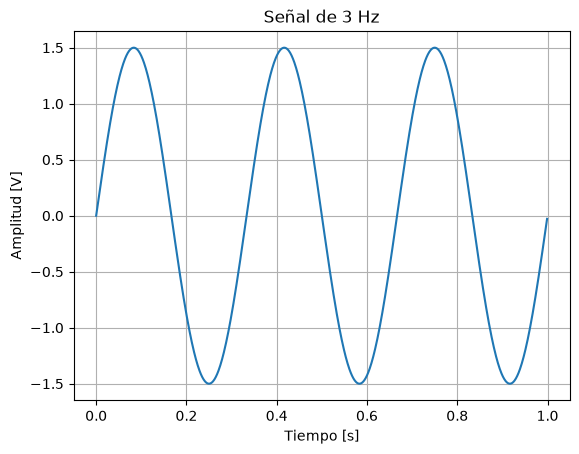

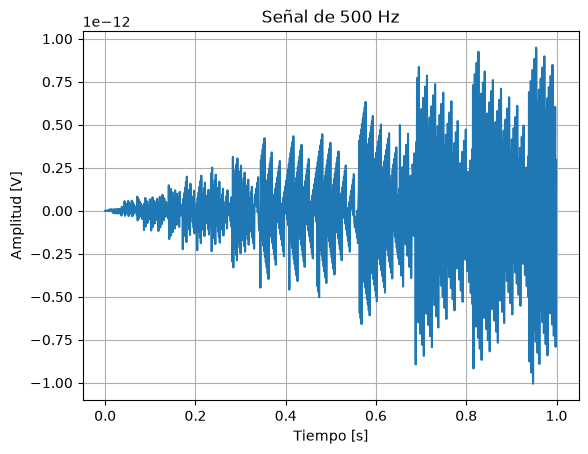

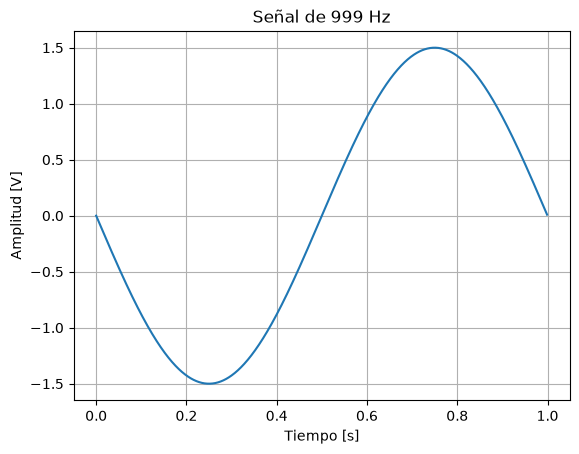

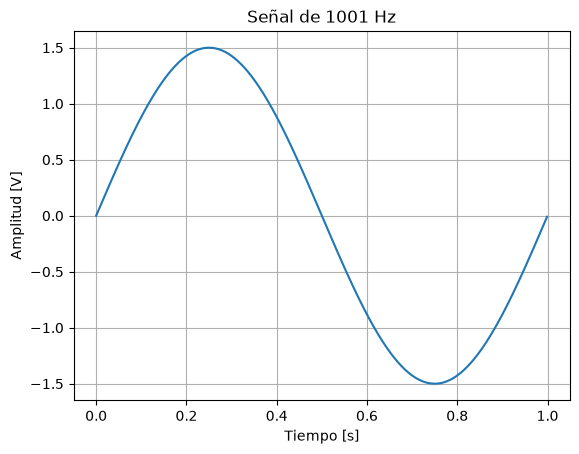

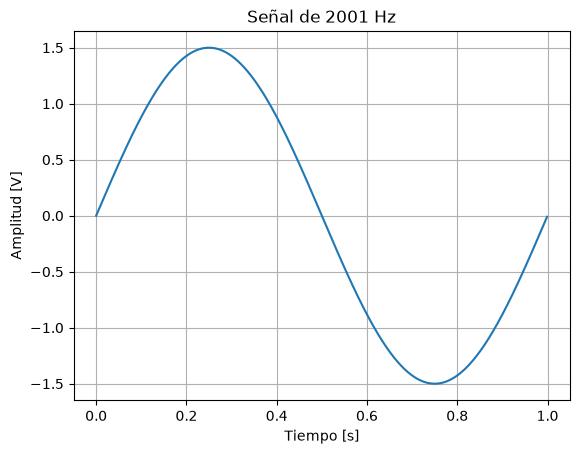

In [4]:
# Script

# Primero pruebo con ff=3 a ver si dibuja la senoidal
# Después le paso las ff del Bonus

frecuencias = [3, 500, 999, 1001, 2001]

vmax = 1.5 # amplitud
dc = 0 # offset
ph = 0 # fase

for ff in frecuencias:
    
    tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn=N, fs=fs)
    
    plt.figure()
    plt.plot(tt, xx)
    plt.title("Señal de " + str(ff) + " Hz")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.grid()
    plt.show()
    
# Nyquist = fs / 2 = 500 Hz -> Aliasing?
# Frecuencia: velocidad angular -> frecuencia negativa: velocidad angular que
# gira en la dirección opuesta.

## 5. Frecuencia aparente debido al aliasing

Cuando una señal tiene una frecuencia superior a la frecuencia de Nyquist,
el muestreo puede hacer que sea observada como una señal de una frecuencia
diferente.

Para las señales de 999 Hz y 1001 Hz, con una frecuencia de muestreo de
1000 Hz:

$$
f_{alias,999} = |999 - 1000| = 1\ \text{Hz}
$$

$$
f_{alias,1001} = |1001 - 1000| = 1\ \text{Hz}
$$

Por este motivo, ambas señales aparecen como señales de aproximadamente
1 Hz en las muestras obtenidas, pero desfasadas una con respecto a la otra.